<a href="https://colab.research.google.com/github/NurulZayanah/Ecommerce-Sales/blob/main/Ecommerce_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
df = pd.read_csv("ecommerce_sales_data.csv")
df.head()

,Order ID,Date,Region,Category,Product,Customer,Sales,Quantity,Profit,Discount
0,ORD-0001,3/8/2025,East,Clothing,Shoes,CUST-088,344.00,5.0,140.31,20.00%
1,ORD-0002,11/7/2025,West,Electronics,Keyboard,CUST-021,1889.55,3.0,371.47,15.00%
2,ORD-0003,19/6/2025,West,Electronics,Keyboard,CUST-015,181.80,2.0,51.78,10.00%
3,ORD-0004,3/11/2025,East,Furniture,Desk,CUST-021,2821.00,7.0,1234.07,0.00%
4,ORD-0005,12/12/2025,North,Electronics,Headphones,CUST-130,887.30,2.0,306.95,5.00%


In [88]:
df=df.map(lambda x: x.title() if isinstance(x, str) else x)

In [89]:
df.shape

(502, 10)

In [90]:
df.columns

Index(['Order ID', 'Date', 'Region', 'Category', 'Product', 'Customer',
       'Sales', 'Quantity', 'Profit', 'Discount'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order ID  500 non-null    object 
 1   Date      500 non-null    object 
 2   Region    500 non-null    object 
 3   Category  500 non-null    object 
 4   Product   499 non-null    object 
 5   Customer  501 non-null    object 
 6   Sales     500 non-null    float64
 7   Quantity  500 non-null    float64
 8   Profit    500 non-null    float64
 9   Discount  499 non-null    object 
dtypes: float64(3), object(7)
memory usage: 39.3+ KB


In [92]:
df.describe()

,Sales,Quantity,Profit
count,500.000000,500.000000,500.000000
mean,821.656600,3.992000,253.269960
std,973.339498,2.015952,313.965167
min,12.000000,1.000000,2.240000
25%,157.875000,2.000000,47.850000
50%,413.525000,4.000000,128.605000
75%,1089.225000,6.000000,322.550000
max,5131.000000,7.000000,2161.280000


In [93]:
df.isnull().sum()

,0
Order ID,2
Date,2
Region,2
Category,2
Product,3
Customer,1
Sales,2
Quantity,2
Profit,2
Discount,3


In [94]:
df[df.isnull().any(axis=1)]

,Order ID,Date,Region,Category,Product,Customer,Sales,Quantity,Profit,Discount
126,Ord-0127,2/7/2025,East,Clothing,Shoes,Cust-108,141.6,3.0,43.45,NaN
211,Ord-0212,17/9/2025,East,Electronics,NaN,Cust-040,1734.0,5.0,490.94,15.00%
500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
501,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN


In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df.dtypes

,0
Order ID,object
Date,object
Region,object
Category,object
Product,object
Customer,object
Sales,float64
Quantity,float64
Profit,float64
Discount,object


In [97]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [98]:
df.dtypes

,0
Order ID,object
Date,datetime64[ns]
Region,object
Category,object
Product,object
Customer,object
Sales,float64
Quantity,float64
Profit,float64
Discount,object


In [99]:
df = df.dropna()

In [100]:
df.isnull().sum()

,0
Order ID,0
Date,0
Region,0
Category,0
Product,0
Customer,0
Sales,0
Quantity,0
Profit,0
Discount,0


In [101]:
df.shape

(498, 10)

In [114]:
#EDA
#highest months
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Total sales for each month
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum()

# Show highest sales months
monthly_sales.sort_values(ascending=False).head()


Year  Month
2025  8        45807.95
      11       44763.45
      6        44346.95
      3        36567.10
      1        36351.45
Name: Sales, dtype: float64

In [115]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_sales)

Highest Sales Month: (np.int32(2025), np.int32(8))
Highest Sales: 45807.95


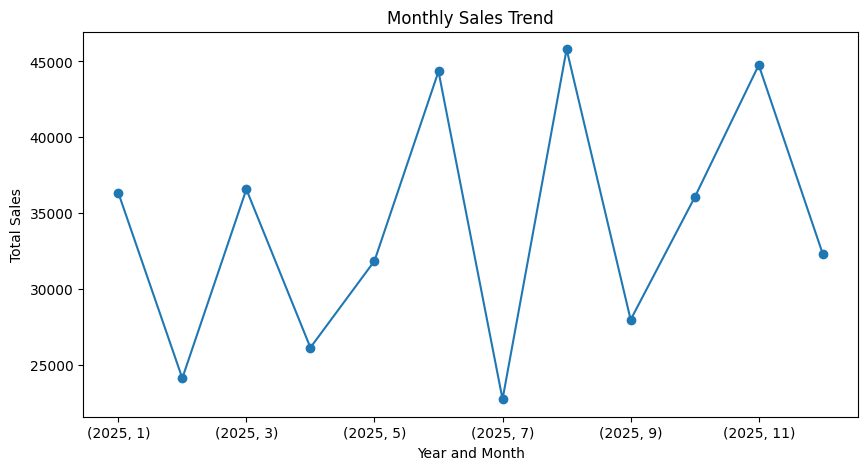

In [104]:
#visualize
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Year and Month")
plt.ylabel("Total Sales")
plt.show()

In [117]:
#category with most profit

category_profit = df.groupby("Category")["Profit"].sum()
category_profit.sort_values(ascending=False)


,Profit
Category,
Electronics,64857.80
Furniture,41193.62
Clothing,11465.89
Office Supplies,8583.28


In [118]:
#highest
category_profit.idxmax(), category_profit.max()

('Electronics', 64857.8)

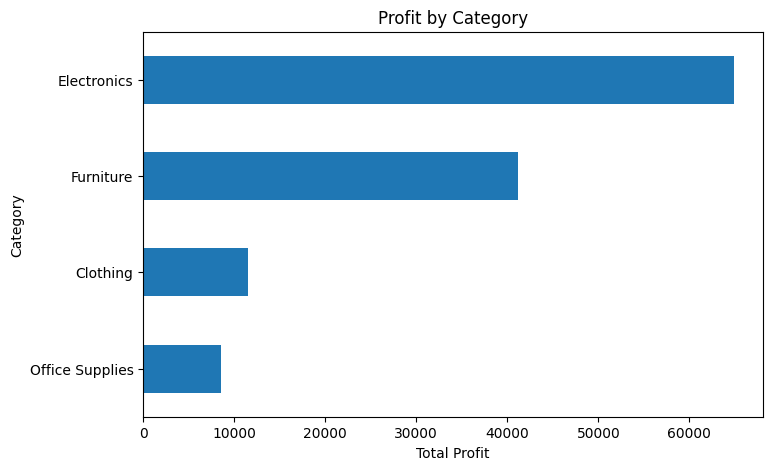

In [119]:
#chart
category_profit.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")
plt.show()

In [120]:
#top 10 customer
customer_sales = df.groupby("Customer")["Sales"].sum()
top_10_customers = customer_sales.sort_values(
    ascending=False
).head(10)
print(top_10_customers)

Customer
Cust-021    13561.50
Cust-147     9848.80
Cust-014     8547.25
Cust-063     8416.65
Cust-032     7681.85
Cust-017     7549.95
Cust-031     7544.75
Cust-075     7401.40
Cust-072     7257.65
Cust-103     7187.10
Name: Sales, dtype: float64


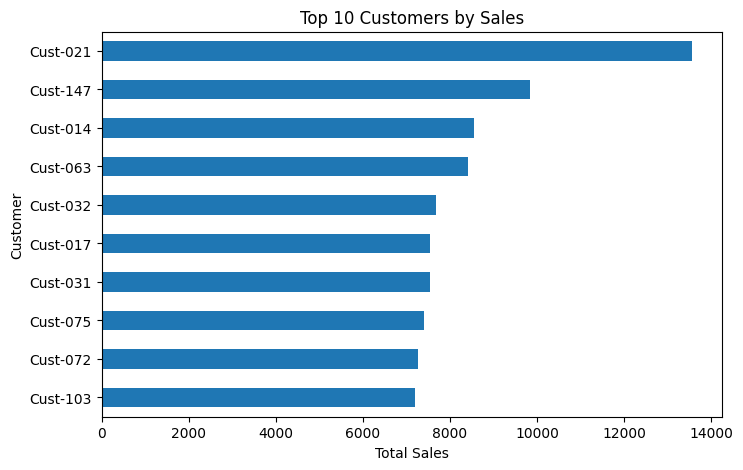

In [121]:
top_10_customers.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.show()

In [122]:
#region that performs the best
region_performance = df.groupby("Region")[["Sales", "Profit"]].sum()
region_performance
region_performance.sort_values(
    "Profit",
    ascending=False
)


,Sales,Profit
Region,,
North,115429.95,37164.31
West,107687.55,32098.70
East,102473.30,31208.36
South,83361.90,25629.22


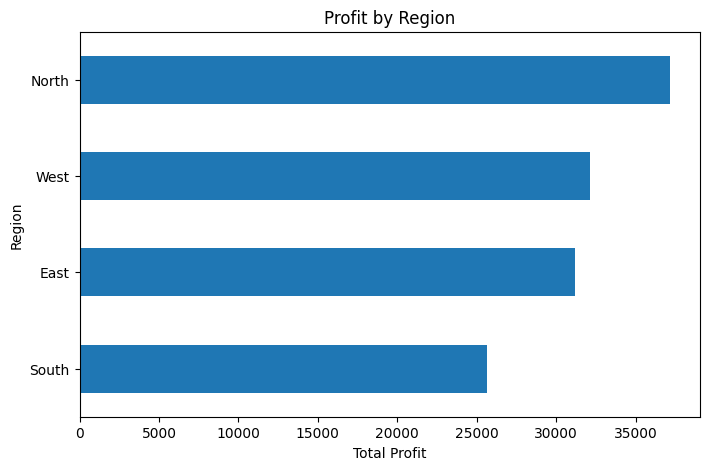

In [123]:
region_performance["Profit"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")
plt.show()

In [124]:
#KPI
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
profit_margin = (total_profit / total_sales) * 100
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Profit Margin:", profit_margin)


Total Sales: 408952.69999999995
Total Profit: 126100.59
Total Quantity: 1988.0
Total Orders: 498
Profit Margin: 30.835006102172695
